In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style as style
style.use('ggplot')
import seaborn as sns
import pycaret

In [13]:
n = 1000

df = pd.DataFrame({
    'age':np.random.randint(18,80, size = n),
    'income':np.random.normal(50000, 15000, size = n).astype(int),
    'credit_score':np.random.randint(450,850, size = n),
    'loan_amount':np.random.randint(1500, 30000, size = n),
    'loan_term_months': np.random.choice([12, 24, 36, 48, 60], size = n),
    'married':np.random.choice(['Yes', 'No'], size = n),
    'education_level':np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], size = n),
    'defaulted':np.random.choice([0,1], size = n, p = [0.85, 0.15])
})

In [14]:
df.head(4)

,age,income,credit_score,loan_amount,loan_term_months,married,education_level,defaulted
0,26,42837,523,22869,60,No,Bachelor,0
1,68,64127,459,10654,12,No,Bachelor,1
2,40,68252,585,29083,36,No,PhD,0
3,65,48102,556,4416,12,No,High School,0


In [12]:
from pycaret.classification import setup, compare_models

In [16]:
clf_setup = setup(
    data = df,
    target = 'defaulted',
    normalize = True,
    session_id = 101,
    categorical_features = ['education_level', 'married'],
    verbose = True
)

,Description,Value
0,Session id,101
1,Target,defaulted
2,Target type,Binary
3,Original data shape,"(1000, 8)"
4,Transformed data shape,"(1000, 11)"
5,Transformed train set shape,"(700, 11)"
6,Transformed test set shape,"(300, 11)"
7,Numeric features,5
8,Categorical features,2
9,Preprocess,True


In [17]:
best_model = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.8514,0.4582,0.0000,0.0000,0.0000,0.0000,0.0000,0.7050
nb,Naive Bayes,0.8514,0.4753,0.0000,0.0000,0.0000,0.0000,0.0000,0.0300
ridge,Ridge Classifier,0.8514,0.4579,0.0000,0.0000,0.0000,0.0000,0.0000,0.0160
lda,Linear Discriminant Analysis,0.8514,0.4579,0.0000,0.0000,0.0000,0.0000,0.0000,0.0120
dummy,Dummy Classifier,0.8514,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0140
rf,Random Forest Classifier,0.8486,0.5163,0.0000,0.0000,0.0000,-0.0050,-0.0070,0.0470
catboost,CatBoost Classifier,0.8443,0.5130,0.0000,0.0000,0.0000,-0.0130,-0.0220,0.2730
svm,SVM - Linear Kernel,0.8414,0.4889,0.0200,0.0833,0.0321,0.0084,0.0121,0.0160
et,Extra Trees Classifier,0.8386,0.5127,0.0100,0.0500,0.0167,-0.0107,-0.0191,0.0370
gbc,Gradient Boosting Classifier,0.8343,0.5229,0.0491,0.2250,0.0797,0.0306,0.0410,0.0330


In [18]:
from pycaret.classification import create_model, tune_model

In [19]:
rf_model = create_model("rf")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8429,0.4522,0.0000,0.0000,0.0000,0.0000,0.0000
1,0.8429,0.6002,0.0000,0.0000,0.0000,0.0000,0.0000
2,0.8429,0.3367,0.0000,0.0000,0.0000,0.0000,0.0000
3,0.8429,0.4854,0.0000,0.0000,0.0000,0.0000,0.0000
4,0.8571,0.3417,0.0000,0.0000,0.0000,0.0000,0.0000
5,0.8571,0.4575,0.0000,0.0000,0.0000,0.0000,0.0000
6,0.8286,0.5175,0.0000,0.0000,0.0000,-0.0500,-0.0700
7,0.8571,0.6475,0.0000,0.0000,0.0000,0.0000,0.0000
8,0.8571,0.6592,0.0000,0.0000,0.0000,0.0000,0.0000


In [20]:
tuned_rf = tune_model(rf_model)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8429,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000
1,0.8429,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000
2,0.8429,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000
3,0.8429,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000
4,0.8571,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000
5,0.8571,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000
6,0.8571,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000
7,0.8571,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000
8,0.8571,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000


Fitting 10 folds for each of 10 candidates, totalling 100 fits


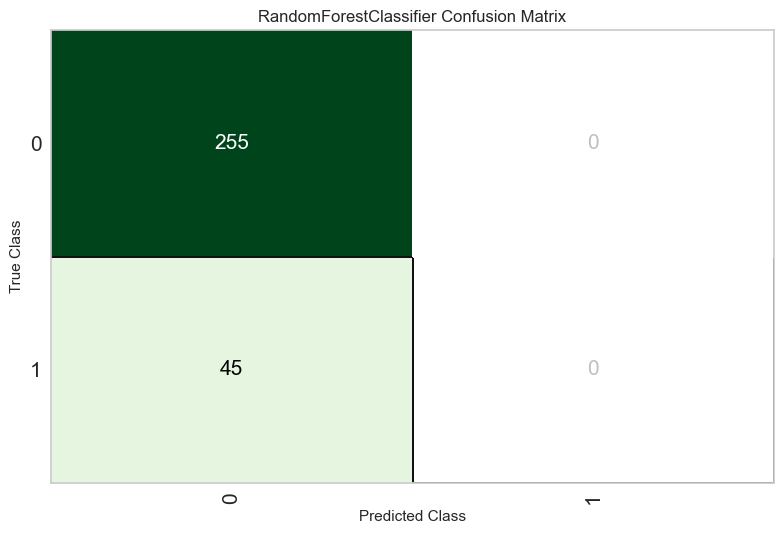

In [22]:
from pycaret.classification import plot_model
plot_model(tuned_rf, plot = "confusion_matrix")

In [26]:
from pycaret.classification import evaluate_model
evaluate_model(tuned_rf)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…